In [252]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [253]:

# TODO: Set weight1, weight2, and bias
weight1 = 1.0
weight2 = 1.0
bias = -1.5


# DON'T CHANGE ANYTHING BELOW
# Inputs and outputs
test_inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
correct_outputs = [False, False, False, True]
outputs = []

# Generate and check output
for test_input, correct_output in zip(test_inputs, correct_outputs):
    linear_combination = weight1 * test_input[0] + weight2 * test_input[1] + bias
    output = int(linear_combination >= 0)
    is_correct_string = 'Yes' if output == correct_output else 'No'
    outputs.append([test_input[0], test_input[1], linear_combination, output, is_correct_string])

# Print output
num_wrong = len([output[4] for output in outputs if output[4] == 'No'])
output_frame = pd.DataFrame(outputs, columns=['Input 1', '  Input 2', '  Linear Combination', '  Activation Output', '  Is Correct'])
if not num_wrong:
    print('Nice!  You got it all correct.\n')
else:
    print('You got {} wrong.  Keep trying!\n'.format(num_wrong))
print(output_frame.to_string(index=False))


Nice!  You got it all correct.

 Input 1    Input 2    Linear Combination    Activation Output   Is Correct
       0          0                  -1.5                    0          Yes
       0          1                  -0.5                    0          Yes
       1          0                  -0.5                    0          Yes
       1          1                   0.5                    1          Yes


## Linear Regression 

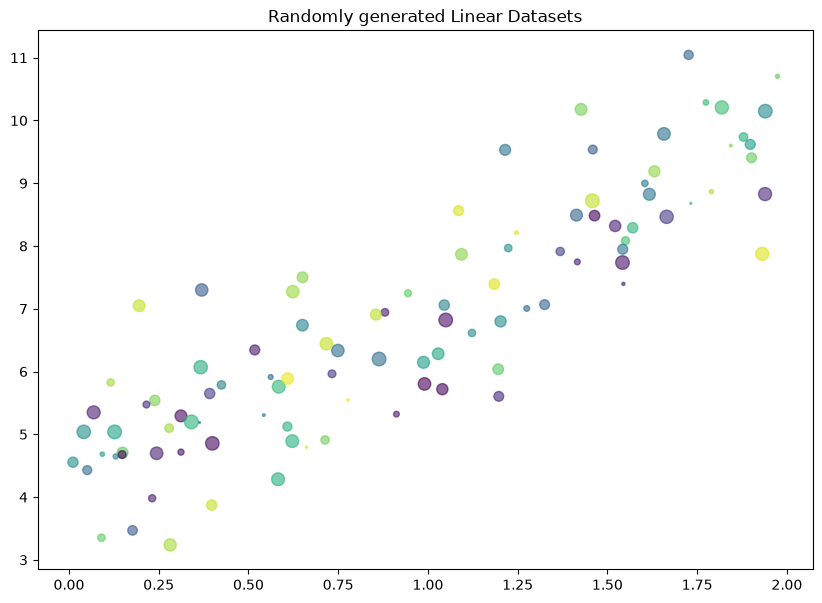

In [254]:
# using Normal equation
np.random.seed(42)

X=2*np.random.rand(100,1) 

y=4+3*X + np.random.randn(100,1)
fig,ax=plt.subplots(figsize=(10,7))
size=np.random.rand(100)*100
color=np.random.rand(100)
ax.scatter(X,y,cmap='viridis',c=color,s=size,alpha=0.6);
ax.set_title("Randomly generated Linear Datasets")
plt.show()

In [255]:
X_b=np.c_[np.ones((100,1)),X] # adding x0 =1
theta_best=np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) # finding best values of parameter
theta_best

array([[4.21509616],
       [2.77011339]])

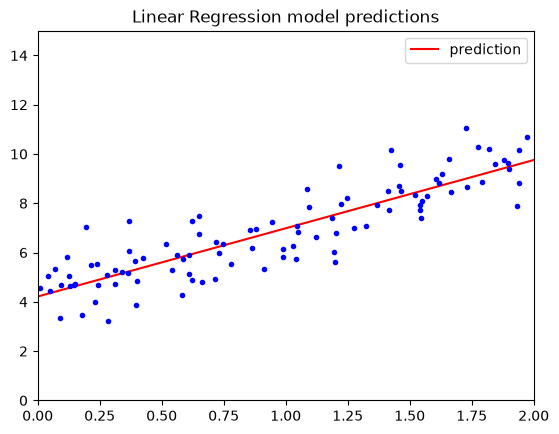

In [256]:
X_new=np.array([[0],[2]]) # new array values 
x_new_b=np.c_[np.ones((2,1)),X_new] # adding x0=1 to X_new 
y_pred=x_new_b.dot(theta_best)
y_predd=theta_best.T.dot(x_new_b)# this is wrong why ? because it is
                                     # Sum of samples weighted by theta for feature i
                                     # but it has to be sum of feature ...for sample i
y_act=4+3*x_new_b


# plot  prediction
plt.plot(X_new, y_pred, 'r-',label='prediction')
plt.plot(X,y,'b.')

#plt.axis([0,2,0,15])
plt.title("Linear Regression model predictions")
plt.legend()
plt.axis ([0,2,0,15])
plt.show()





In [257]:
# Using Scikit learning instead of normal equation
from sklearn.linear_model import LinearRegression
ling_reg=LinearRegression()
ling_reg.fit(X,y)
ling_reg.coef_, ling_reg.intercept_


(array([[2.77011339]]), array([4.21509616]))

In [258]:
# using  SVD(singular values decomposition) for linear regression

theta_best_svd,residual,rank,s =np.linalg.lstsq(X_b,y) ## least_square 
print("best theta saved values is : ",theta_best_svd)
## Pseudo - moore ..... 
np.linalg.pinv(X_b).dot(y)


best theta saved values is :  [[4.21509616]
 [2.77011339]]


array([[4.21509616],
       [2.77011339]])

## Gradient descent 
 We need gradient vector , which is partial derivate of the cost function 
  $$ \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = \begin{pmatrix} \frac{\partial}{\partial \theta_0} \text{MSE}(\boldsymbol{\theta}) \\ \frac{\partial}{\partial \theta_1} \text{MSE}(\boldsymbol{\theta}) \\ \vdots \\ \frac{\partial}{\partial \theta_n} \text{MSE}(\boldsymbol{\theta}) \end{pmatrix} = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \boldsymbol{\theta} - \mathbf{y}) $$




$$ \boldsymbol{\theta}^{(\text{next step})} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) $$


In [259]:
# Gradient descent Implementation
eta=0.1
# learning rate 
n_iteration=1000 # numbers of iteration
m=len(X_b) #  numbers of instance
np.random.seed(42)
initial_theta=np.random.randn(X_b.shape[1],1) # randomly initializing theta

theta=initial_theta.copy()

for iteration in range ( n_iteration ):
  gradient=(2/m)*X_b.T.dot(X_b.dot(theta)-y) # gradient vector 
  theta=theta-eta*gradient # Gradient steps

    
   

## Gradient Descent Implementation for Linear regression

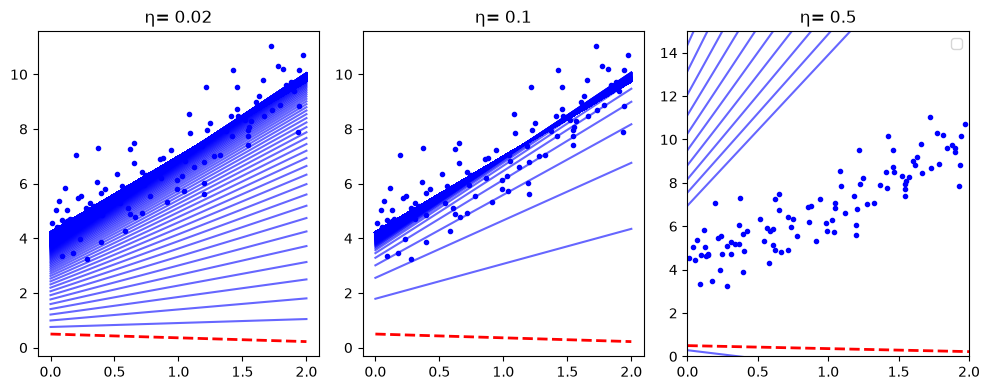

In [260]:
# new array values 

eta=[0.02,0.1,0.5]
#X_new=np.random.uniform(-50,50, 100)

#X_new=np.c_[np.ones((100,1)),X_new]

fig,axes=plt.subplots(1,3, figsize=(10,4))
bgd_theta_path=[]


for i ,ax in zip ( eta, axes.ravel()):
    
    theta=initial_theta.copy()

    X_new=np.array([[0],[2]])
    
    X_new_b=np.c_[np.ones((2,1)),X_new]
    
    y_pred=X_new_b.dot(theta) 
    
    
    ax.plot(X_new,y_pred,'r--',linewidth=2) # starting point of the learning rate 
    
    for iteration in range (n_iteration):
        if i==0.1:
            bgd_theta_path.append(theta)
            
        
       
        gradient=(2/m)*X_b.T.dot(X_b.dot(theta)-y) # gradient vector
        
        
        
        theta=theta-i*gradient # Gradient steps 
        
        y_pred=X_new_b.dot(theta) # prediction by new values of theta 
        
        ax.plot(X_new,y_pred,"b-",alpha=0.6) # plot   
        
       
    
    ax.plot(X,y,"b.")
    #ax.set_xlim(0,2)
    #ax.set_ylim(0,15)
    ax.set_title(f"η= {i}")
    
plt.axis([0,2,0,15])
plt.legend()
plt.tight_layout()
plt.show()        
        
    



## Stochastic Gradient Descent(SGD)

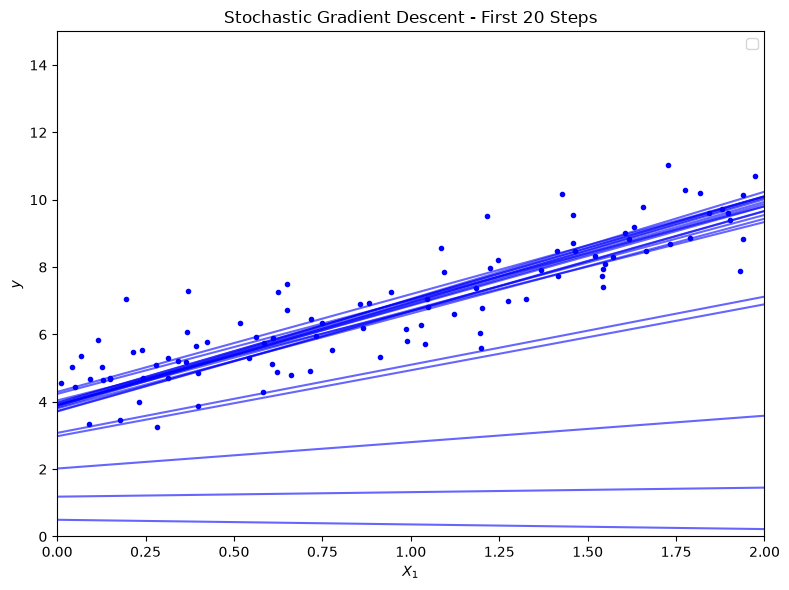

In [261]:
#  implements Stochastic Gradient Descent using a simple learning schedule


np.random.seed(42)
n_epochs=50 # number of iteration

t0,t1= 5, 50 # learning schedule hyperparameters
# leaarning schedule function

def learning_schedule(t): 
    return t0/(t+t1) # popular math formula of the this function
                     # t is iteration or step number 
sgd_theta_path=[] 

    
   
theta = np.random.randn(2,1) # random initialization

counter_step=0 # step _counter for plotting first 20

X_new=np.array([[0],[2]])
    
X_new_b=np.c_[np.ones((2,1)),X_new] 
   
        
y_pred=X_new_b.dot(theta)
plt.figure(figsize=(8, 6))


for epoch in range (n_epochs):
    
    

    for i in range(m):
        # plotting first 19 iteration
        if epoch== 0 and i<20:
            y_pred=X_new_b.dot(theta)
            plt.plot(X_new,y_pred,"b",alpha=0.6)
            
            
            
        
        sgd_theta_path.append(theta)
        
        random_index=np.random.randint(m) # randomly selecting index
        
        x_i=X_b[random_index:random_index+1]
        
        y_i=y[random_index:random_index+1]

        gradient =2  * x_i.T.dot(x_i.dot(theta)-y_i) # gradient vectorfor randomly-
                                                        # selected single data point
        # calculate iteration step number t
        t=epoch * m + i 
       
        # get dynamically reduced learning rate for this step
        eta=learning_schedule(t)
        
        # update theta values 
        theta = theta- eta*gradient 
        # 
        
    
        
 
        
plt.plot(X,y,"b.")
plt.axis([0,2,0,15]) 
plt.xlabel("$X_1$")
plt.ylabel("$y$")
plt.title("Stochastic Gradient Descent - First 20 Steps")
plt.legend()
plt.tight_layout()
plt.show()   

     
          
          
        
      
 
        
        

    
    
    

In [262]:
# SGD by using scikit learn 
from sklearn.linear_model import SGDRegressor 

sgd_reg=SGDRegressor(max_iter=1000, penalty=None, eta0=0.1)
sgd_reg.fit(X,y)



,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",0.1
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1


In [263]:
sgd_reg.coef_, sgd_reg.intercept_

(array([2.73198364]), array([4.19984658]))

Mini batch GD  started training.....
Mini batch GD training is completed successfully!


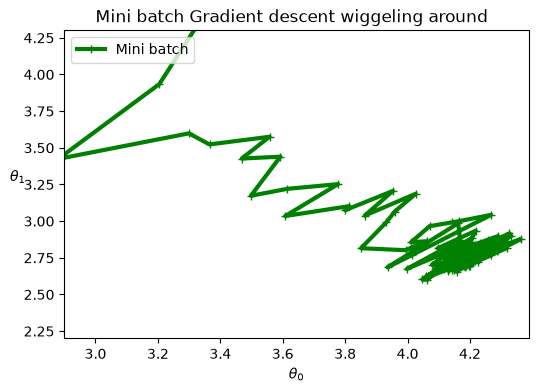

In [264]:
# Mini batch SG
from math import ceil
n_epochs=50
minibatches_size=20
batches_per_epoch=ceil(m/minibatches_size)
t0, t1=50,200

np.random.seed(42)
theta=np.random.rand(2,1)

def learning_schedule(t):
    return t0/(t+t1)
mini_batch_gd_path=[]
print(f"Mini batch GD  started training.....")
for epoch in range(n_epochs):
    # shuffle data at every epoch
    shuffle_indices=np.random.permutation(m)
    X_b_shuffle=X_b[shuffle_indices]
    y_shuffle=y[shuffle_indices]
    
    
    for iteration in range(0,batches_per_epoch):
        
        idx=iteration*minibatches_size
        X_idx=X_b_shuffle[idx:idx+minibatches_size]
        y_idx=y_shuffle[idx:idx+minibatches_size]
        gradients=2/minibatches_size * X_idx.T@(X_idx@theta-y_idx)
        eta=learning_schedule(epoch*batches_per_epoch+iteration)
        theta=theta-eta*gradients
        mini_batch_gd_path.append(theta)



   


print("Mini batch GD training is completed successfully!")
plt.figure(figsize=(6,4))
plt.plot(np.array(mini_batch_gd_path)[:,0],np.array(mini_batch_gd_path)[:,1],'g-+', 
                    label='Mini batch', linewidth=3)
plt.legend(loc='upper left')
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$",rotation=0)
plt.axis([2.9,4.39,2.2,4.3])
plt.title("Mini batch Gradient descent wiggeling around  ")
plt.show()





In [265]:
from math import ceil
n_epochs=50
minibatches_size=20
batches_per_epoch=ceil(m/minibatches_size)
shuffle_indices=np.random.permutation(m)

X_b_shuffle=X_b[shuffle_indices]

y_shuffle=y[shuffle_indices]
for i in range(batches_per_epoch)    :
    idx=i*minibatches_size
    X_idx=X_b_shuffle[idx:idx+minibatches_size]
    print(X_idx)
    print(len(X_idx))
    break

    

[[1.         0.62196464]
 [1.         0.09290083]
 [1.         0.31203728]
 [1.         0.65036664]
 [1.         0.24407647]
 [1.         1.97377387]
 [1.         0.74908024]
 [1.         0.62342215]
 [1.         0.94442985]
 [1.         0.66179605]
 [1.         0.5842893 ]
 [1.         1.41371469]
 [1.         1.89777107]
 [1.         1.63092286]
 [1.         1.42648957]
 [1.         0.23173812]
 [1.         1.18482914]
 [1.         1.6167947 ]
 [1.         1.46398788]
 [1.         1.55026565]]
20


In [266]:
shuffle_indices=np.random.permutation(m)
X_b_shuffle=X_b[shuffle_indices]


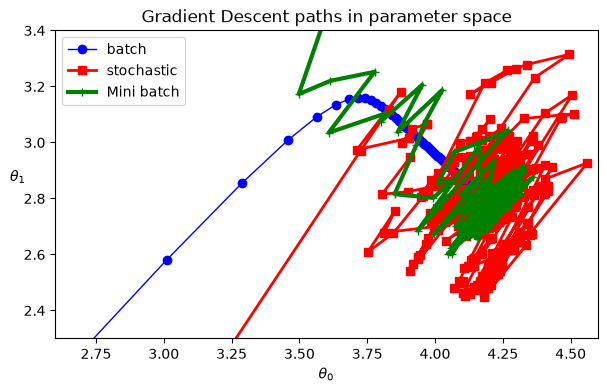

In [267]:
sgd_theta_path=np.array(sgd_theta_path)
bgd_theta_path=np.array(bgd_theta_path)
mini_batch_gd_path=np.array(mini_batch_gd_path)
plt.figure(figsize=(7,4))
plt.plot(bgd_theta_path[:,0],bgd_theta_path[:,1],'b-o',label='batch',linewidth=1)
plt.plot(sgd_theta_path[:,0],sgd_theta_path[:,1],"r-s",label='stochastic',linewidth=2)
plt.plot(mini_batch_gd_path[:,0],mini_batch_gd_path[:,1],'g-+', label='Mini batch', linewidth=3)
plt.axis([2.6,4.6,2.3,3.4])
plt.xlabel(r"$\theta_0 $")
plt.ylabel(r"$\theta_1 $",rotation=0)
plt.title("Gradient Descent paths in parameter space")
plt.legend(loc='upper left')
plt.show()


## Polynomial Regression

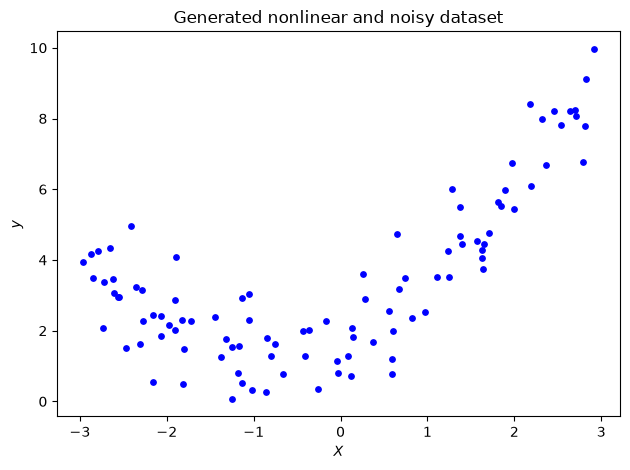

In [268]:
np.random.seed(42)

def scatter_plots(X,y
                  ,title):
    return ( plt.scatter(X,y,color='b',s=15),
            #plt.xlim(0,2),
            #plt.ylim(0,15),
            plt.xlabel("$X$"),
            plt.ylabel("$y$"),
            plt.title(title),
            plt.tight_layout(),
            plt.show())

# polynomial regression


m=100 # training instance

X=6*np.random.rand(m,1)-3# generating training points
y=0.5*X**2 + X +2 + np.random.randn(m,1)  # quadratic equation to get nonlinear data 
plot=scatter_plots(X,y, "Generated nonlinear and noisy dataset")

In [269]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
poly_features=PolynomialFeatures(degree=2, include_bias=False)
X_poly=poly_features.fit_transform(X)   #  
lin_reg.fit(X_poly,y)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[0.93,0.56]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.78]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[26.82,17.58]"


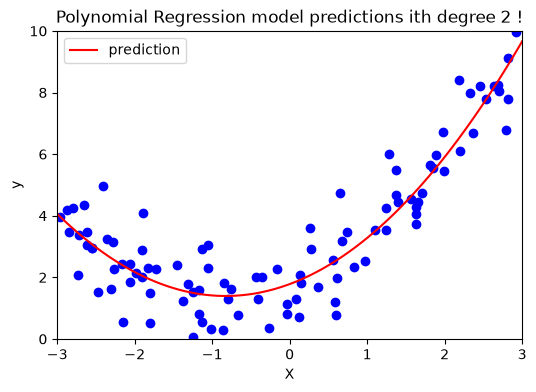

In [270]:
np.random.seed(42)
X_test=np.linspace(-3,3, 100).reshape(100,1) # new test data points

X_testpoly=poly_features.transform(X_test)  # transform test datapoints

                


y_pred=lin_reg.predict(X_testpoly) # predict 


# plot
plt.figure(figsize=(6,4))
plt.scatter(X,y,color='blue')

plt.plot(X_test,y_pred,'r',label="prediction")
plt.xlabel("X")

plt.ylabel('y')

plt.axis([-3,3,0,10])
plt.title("Polynomial Regression model predictions ith degree 2 !")
plt.legend()

plt.show()

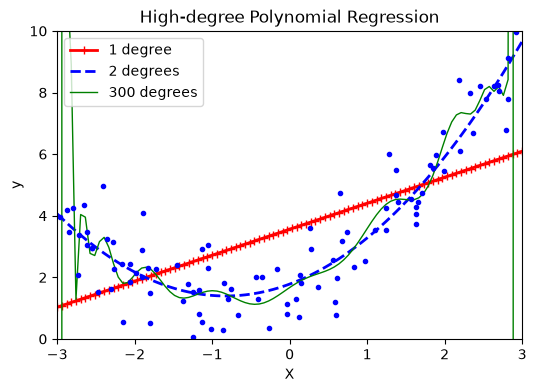

In [271]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
np.random.seed(42)
X_test=np.linspace(-3,3, 100).reshape(100,1) 
plt.figure(figsize=(6,4))

for style,width,degree in (('r-+',2,1),('b--',2,2),('g-',1,300)):
    std_scaler=StandardScaler()
    poly_feat=PolynomialFeatures(degree=degree, include_bias=False)
    lin_reg=LinearRegression()
    polynomial_reg_pipeline=make_pipeline(poly_feat,std_scaler,lin_reg)
    polynomial_reg_pipeline.fit(X,y)
    y_predict=polynomial_reg_pipeline.predict(X_test)
    label=f"{degree} degree{'s' if degree>1 else''}"
    plt.plot(X_test,y_predict,style,label=label,linewidth=width)
plt.plot(X,y,'b.',linewidth=3)
plt.axis([-3,3,0,10])
plt.xlabel("X")

plt.ylabel('y')
plt.legend(loc='upper left')
plt.title('High-degree Polynomial Regression')
plt.show()
    

    
    
    



    
              



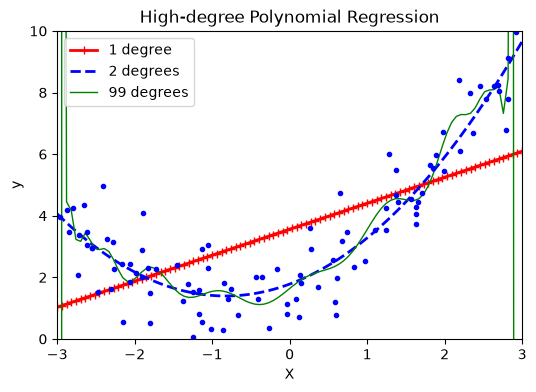

In [272]:
np.random.seed(42)
X_test=np.linspace(-3,3, 100).reshape(100,1) 
plt.figure(figsize=(6,4))

for style,width,degree in (('r-+',2,1),('b--',2,2),('g-',1,99)):
    std_scaler=StandardScaler()
    poly_feat=PolynomialFeatures(degree=degree, include_bias=False)
    lin_reg=LinearRegression()
    polynomial_reg_pipeline=make_pipeline(poly_feat,std_scaler,lin_reg)
    polynomial_reg_pipeline.fit(X,y)
    y_predict=polynomial_reg_pipeline.predict(X_test)
    label=f"{degree} degree{'s' if degree>1 else''}"
    plt.plot(X_test,y_predict,style,label=label,linewidth=width)
plt.plot(X,y,'b.',linewidth=3)
plt.axis([-3,3,0,10])
plt.xlabel("X")

plt.ylabel('y')
plt.legend(loc='upper left')
plt.title('High-degree Polynomial Regression')
plt.show()

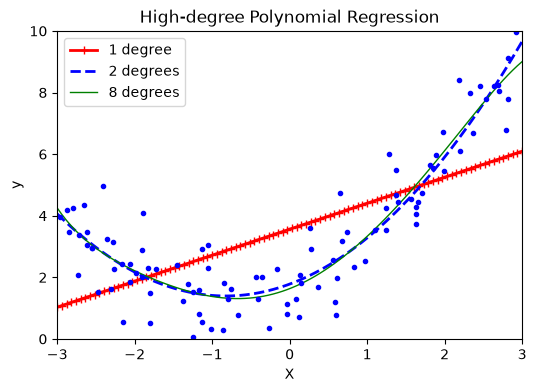

In [273]:
np.random.seed(42)
X_test=np.linspace(-3,3, 100).reshape(100,1) 
plt.figure(figsize=(6,4))

for style,width,degree in (('r-+',2,1),('b--',2,2),('g-',1,8)):
    std_scaler=StandardScaler()
    poly_feat=PolynomialFeatures(degree=degree, include_bias=False)
    lin_reg=LinearRegression()
    polynomial_reg_pipeline=make_pipeline(poly_feat,std_scaler,lin_reg)
    polynomial_reg_pipeline.fit(X,y)
    y_predict=polynomial_reg_pipeline.predict(X_test)
    label=f"{degree} degree{'s' if degree>1 else''}"
    plt.plot(X_test,y_predict,style,label=label,linewidth=width)
plt.plot(X,y,'b.',linewidth=3)
plt.axis([-3,3,0,10])
plt.xlabel("X")

plt.ylabel('y')
plt.legend(loc='upper left')
plt.title('High-degree Polynomial Regression')
plt.show()

## Note 
    -  If a model performs well on the training data but generalizes poorly
       according to the cross-validation metrics, then your model is overfitting. If it per
       forms poorly on both, then it is underfitting. This is one way to tell when a model is
       too simple or too complex. 

     - Another way is to look at the learning curves: these are plots of the model’s perfor
       mance on the training set and the validation set as a function of the training set size
       (or the training iteration)

## Learning Curve 

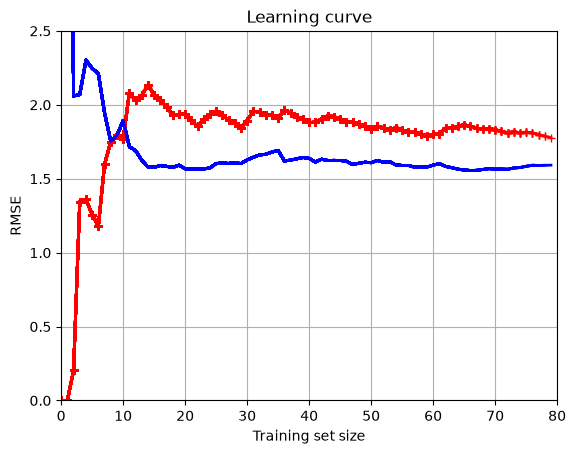

In [274]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#
np.random.seed(42)
# inorder to understand the model's movement we train model on each of instance one by one
# and calculate its ms_error
def learning_curve(model,X,y,title=None):
    X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2)
    train_error,val_error=[],[]
    
    for m in range (1,len(X_train)+1):
        model.fit(X_train[:m],y_train[:m])
        y_pred=model.predict(X_train[:m]) # 'did the model undertand the data' we are about
                                             # to check best model to train
        y_val_pred=model.predict(X_val)
        train_error.append(mean_squared_error(y_pred,y_train[:m]))
        val_error.append(mean_squared_error(y_val_pred,y_val))
        plt.plot(np.sqrt(train_error),'r-+',linewidth=2,label='train_error')
        plt.plot(np.sqrt(val_error),'b-',linewidth=2,label='val_error')
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    
    plt.grid()
    
    plt.axis([0, 80, 0, 2.5])
    plt.title(title) 
    plt.show()
   

lin_reg=LinearRegression()
learning_curve(lin_reg,X,y,title='Learning curve') ;


    



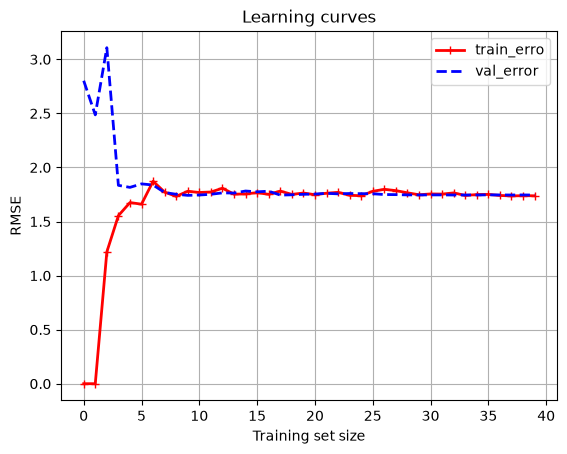

In [275]:
# learning implementation by using sklearn
from sklearn.model_selection import learning_curve
train_zize, train_score,val_score=learning_curve (LinearRegression(),X,y,
                                                train_sizes=np.linspace(0.01,1.0,40),cv=5,
                                               scoring='neg_root_mean_squared_error')
train_error=-train_score.mean(axis=1)
val_error=-val_score.mean(axis=1)

plt.plot(train_error, 'r-+',linewidth=2, label="train_erro")
plt.plot(val_error,'b--',linewidth=2,label="val_error")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
#plt.axis([0, 80, 0, 2.5])
plt.title("Learning curves")

plt.show()

## Note
    - As you see Above model is clearly underfitting.  
    - If your model is underfitting the training data, adding more training examples will not help. 
    - You need to use a more complex model or come up with better features.so let's try Polynomial with degree 10.

In [276]:
#  learning curves of a 10th-degree polynomial model on the samedata 
from sklearn.pipeline import Pipeline
polynomail_model=Pipeline([('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
                             ('lin_reg', LinearRegression())])



learning_curve((polynomail_model),X,y)




(array([ 8, 26, 44, 62, 80]),
 array([[1.        , 0.99615223, 0.99615223, 0.99615223, 0.99615223],
        [0.90625736, 0.95390786, 0.94632747, 0.94632747, 0.94632747],
        [0.87155966, 0.90723635, 0.90277121, 0.90452599, 0.90452599],
        [0.87250444, 0.88412836, 0.88708652, 0.87133002, 0.87603614],
        [0.8552062 , 0.86700169, 0.87428347, 0.86155697, 0.86853625]]),
 array([[-7.44859608e+05, -5.78713162e+00, -1.22755134e+01,
         -1.42309797e+02, -2.63464816e+01],
        [ 8.11541254e-01,  6.64853901e-01,  7.50979176e-01,
          8.25324242e-01,  7.32602703e-01],
        [ 8.46596000e-01,  6.69831320e-01,  7.65834999e-01,
          7.89253255e-01,  8.18472304e-01],
        [ 8.18428124e-01,  7.49930654e-01,  7.83134070e-01,
          8.00476867e-01,  7.91303518e-01],
        [ 8.47048716e-01,  7.82305399e-01,  7.74001409e-01,
          7.72947108e-01,  7.97838793e-01]]))

In [277]:
polynomail_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly_features', ...), ('lin_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",10
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06


## Note
    - As we can see above  Polynomial with degree 10 is over-fitting,
      because there is a gap between training error and validation error 
    - one way to improve an overfitting model is to feed it more training
      data until the validation error reaches the training error.


## The Bias/Variance Tradeof

Bias
   
    This part of the generalization error is due to wrong assumptions, such as assum
    ing that the data is linear when it is actually quadratic,
    A high-bias model is most likely to underfit the training data.
   
Variance

    This part is due to the model’s excessive sensitivity to small variations in the
    training data. A model with many degrees of freedom (such as a high-degree pol
    ynomial model) is likely to have high variance, and thus to overfit the training
    data.
Irreducible error

    This part is due to the noisiness of the data itself. The only way to reduce this
    part of the error is to clean up the data (e.g., fix the data sources, such as broken
    sensors, or detect and remove outliers). 


Increasing a model’s complexity will typically increase its variance and reduce its bias.
Conversely, reducing a model’s complexity increases its bias and reduces its variance. 
This is why it is called a tradeoff.    
   

## Note 
    a good way to reduce overfitting is to regularize the model (i.e., to constrain it): the fewer degrees of freedom it has, the harder it will be
    for it to overfit the data. For example, a simple way to regularize a polynomial model
    is to reduce the number of polynomial degrees. 

## Ridge Regression


In [278]:
np.linspace(0,3,100).reshape(100,1).shape

(100, 1)

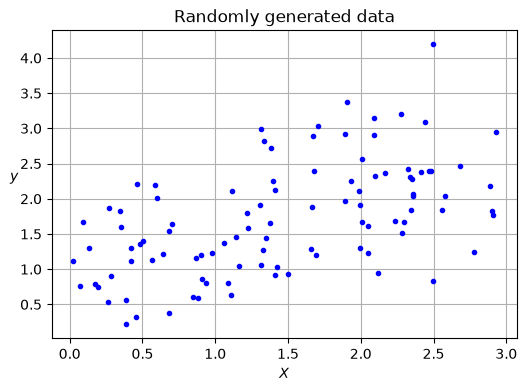

In [279]:
# Redge regression for closed form
rng = np.random.default_rng(seed=42)
M =20 # number of instances
X =3 * rng.random((m,1))
y=1+0.5*X + rng.standard_normal((m,1))/1.5 
X_new = np.linspace(0,3,100).reshape(100,1)
plt.figure(figsize=(6,4))
plt.plot(X,y,'b.')
plt.xlabel('$X$')
plt.ylabel('$y$', rotation=0)
plt.title('Randomly generated data')
plt.grid()
plt.show()

## Note 
    Equation of  Ridge Regression closed-form solution:
    
    

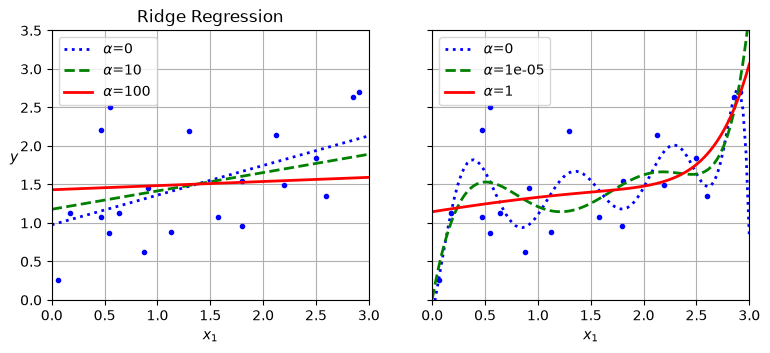

In [280]:
# Ridge regression for Normal equation
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


np.random.seed(42)
M= 20 # number of instances
X=3*np.random.rand(M,1)
y=1+0.5*X + np.random.randn(M,1)/1.5
X_new=np.linspace(0,3,100).reshape(100,1)
def plot_model(model_class,polynomial,alphas,**model_kwargs):
    plt.plot(X,y,'b.')
    for alpha,style in zip(alphas, ('b:','g--','r-')):
        if alpha > 0:
            model=model_class(alpha,**model_kwargs)
        else :
            model=LinearRegression()
        if polynomial :
            model=make_pipeline(PolynomialFeatures(degree=10,include_bias=False),
                               StandardScaler (),
                                model_class(alpha,**model_kwargs))

        model.fit(X,y)
        y_pred=model.predict(X_new)
        plt.plot(X_new,y_pred,style,linewidth=2,label=fr'$\alpha$={alpha}')
    plt.legend(loc='upper left')
    plt.axis([0,3,0,3.5])
    plt.xlabel('$x_1$')
    
    plt.grid()
plt.figure(figsize=(9,3.5)) 
plt.subplot(121)
plot_model(Ridge,polynomial=False,alphas=(0,10,100))
plt.ylabel('$y$',rotation=0)
plt.title("Ridge Regression")
plt.subplot(122)
plot_model(Ridge,polynomial=True,alphas=(0,10**-5,1))
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()
        
        
                                


In [281]:
# using SGD  by adding regularization term
 # so SGD regressor with penalty(l2) is ridge regression with SGD 
sgd_reg=SGDRegressor(penalty='l2', alpha=0.1/M,tol=None, # penalty is not 12 but it l and 2 as '12'
                    max_iter=1000,eta0=0.01,random_state=42)
sgd_reg.fit(X,y.ravel()) # # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])



array([1.55302613])

## Note 
     IN SGDRegressor, The penalty hyperparameter sets the type of regularization term to use.Specifying "l2" indicates that you want SGD to add a regularization term to the cost function. 
     equal to half the square of the ℓ2 norm of the weight vector: this is simply Ridge
    Regression.

In [282]:
# the same with above SGDrergressor with penalty(l2), 
ridge_model=Ridge(alpha=0.1,solver='sag',random_state=42) # we use Stochastic Average GD (solver="sag")
ridge_model.fit(X,y)
ridge_model.predict([[1.5]])

array([1.55326019])

In [283]:
#X_b=np.c_[(np.ones(M),X)]
#np.eye(X_b.shape).shape
#np.array([[0., 0.], [0., 1.]])

In [284]:
X_b=np.c_[np.ones(M),X]
alpha=0.1
A=np.array([[0., 0.], [0., 1.]])
np.linalg.inv(X_b.T@X_b + alpha * A)@X_b.T@y

array([[0.97898394],
       [0.3828496 ]])

In [285]:
ridge_model.coef_,ridge_model.intercept_

(array([0.38286422]), array([0.97896386]))

## Lasso Regression
    Lasso Regression is another regularized version of Linear Regression: just like Ridge
    Regression, it adds a regularization term to the cost function, but it uses the ℓ1 norm
    of the weight vector instead of half the square of the ℓ2 norm.

    hint:- Lasso is ideal when you suspect that only a small subset of your total features actually have a meaningful predictive relationship with the target variable.
    look below example for practical use 


## 1.
Extra Example 

### Lasso Regression Notes

- **Scale features first** with `StandardScaler`; otherwise, large-scale features are penalized more.
- **`alpha` controls regularization strength:**
  - Small `alpha` → less regularization, more features retained.
  - Large `alpha` → more regularization, more coefficients become zero.
- Use **`LassoCV`** to select the best `alpha` automatically.

In [286]:
 
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Assume X is your feature matrix (n_samples, n_features) and y is your target
# Pipeline handles scaling automatically during cross-validation folds to prevent data leakage
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, random_state=42))
])

lasso_cv.fit(X, y)

# Retrieve the fitted Lasso model from the pipeline
best_lasso = lasso_cv.named_steps['lasso']
print(f"Optimal Alpha selected: {best_lasso.alpha_}")

Optimal Alpha selected: 0.0210490414451202


## cont...

In [287]:
# Get feature names and their corresponding coefficients
feature_names = np.array(['feature_1']) # replace with your feature names 
coefficients = best_lasso.coef_

# Identify selected vs. dropped features
selected_features = feature_names[coefficients != 0]
dropped_features = feature_names[coefficients == 0]

print("Selected Features:", selected_features)
print("Dropped Features:", dropped_features)

Selected Features: ['feature_1']
Dropped Features: []


In [288]:
## LAsso Implementation
from sklearn.linear_model import Lasso
lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([1.53788174])

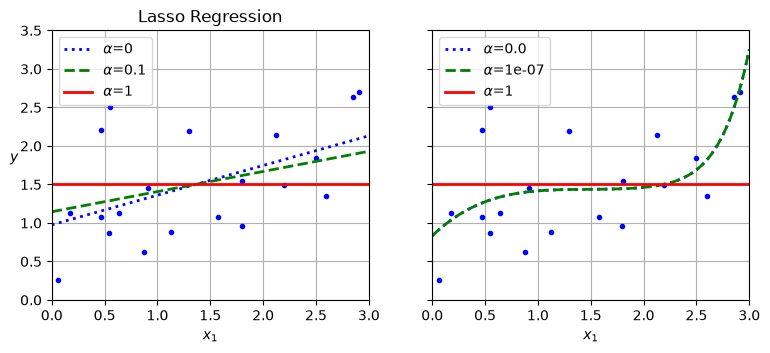

In [289]:
from sklearn.linear_model import Lasso
plt.figure(figsize=(9,3.5))
plt.subplot(121)
plot_model(Lasso,polynomial=False,alphas=(0,0.1,1))
plt.ylabel("$y$", rotation=0)
plt.title("Lasso Regression")
plt.subplot(122)
plot_model(Lasso,polynomial=True,alphas=(0.,10**-7,1))
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()


## Elastic Net
**Elastic Net** is  middle ground b/t **`Ridge`** and **`Lasso`** Regression;
 - **Regularization term** is  a simple mix of both Ridge and Lasso’s regularization terms,
 - **`mix ration(r)`** is controllable,  When **r = 0, Elastic Net** is equivalent to **`Ridge
Regression`**, and when **r = 1**, it is equivalent to **`Lasso Regression`**.

**It is almost always preferable to have at least a little bit of
regularization, so generally you should avoid plain Linear Regression.
Ridge is a good default, but if you suspect that only a few features are actually useful, you should prefer Lasso or Elastic Net since they tend to reduce the useless features’ weights down to zero as we have discussed. In general, Elastic Net is preferred over Lasso since Lasso
may behave erratically when the number of features is greater than the number of
training instances or when several features are strongly correlated.**

In [290]:
# Elastic Net 
from sklearn.linear_model import ElasticNet
elast_net=ElasticNet(alpha=0.1, l1_ratio=0.5) # l1_ratio is mix ration of elasticnet

elast_net.fit(X,y)    
elast_net.predict([[1.5]])


array([1.54333232])

## Early Stopping
  - A very different way to regularize iterative learning algorithms such as Gradient
Descent is to stop training as soon as the validation error reaches a minimum. This is
called **early stopping.**


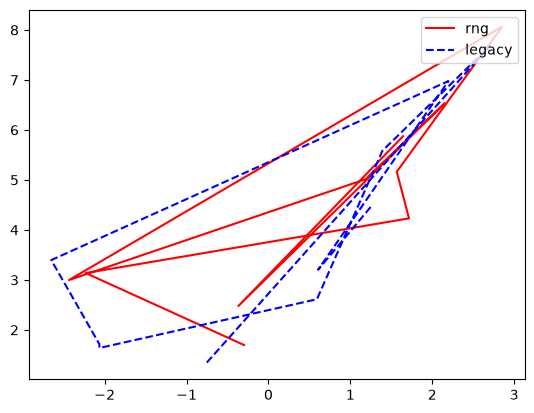

In [291]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
rng=np.random.default_rng(seed=42) # initializing generator
np.random.seed(42)
m=200 # numbers of instances
X_temp=6*rng.random((10,1))-3 # modern rng 
X_tempp=6*np.random.rand(10,1)-3 # legacy random generat
y_temp=0.5 * X_temp**2 + X_temp + 2 + rng.standard_normal((10,1))
y_tempp=0.5 * X_tempp**2 + X_tempp + 2 + rng.standard_normal((10,1))
text="hell0_testing"

plt.plot(X_temp,y_temp,'r',label='rng');
plt.plot(X_tempp,y_tempp,'b--',label='legacy');
plt.legend(loc='upper right')
plt.show()

In [292]:
numbs=[0,1,34,56,-2,7,200,11,-1101,9999]
np.argmax(numbs)

np.int64(9)

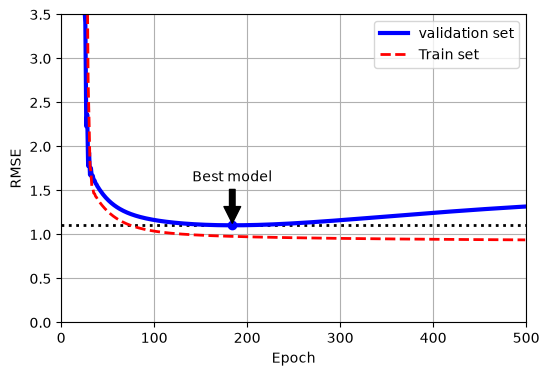

In [293]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler,PolynomialFeatures

from sklearn.pipeline import Pipeline


rng=np.random.default_rng(seed=42) # initializing generator

m=200 # numbers of instances
X=6*rng.random((m,1))-3 
y=0.5 * X**2 + X + 2 + rng.standard_normal((m,1))
X_train , y_train=X[:m//2],y[:m//2,0]  # using 50% of instance for train
                                # in y[:m//2,0] , 0 is used to make 1D or flat result.
                                   # but y[:m//2] does not change D into 1D , it stay the D it is  
X_val,y_val=X[m//2:],y[m//2:,0] # 50% for validation
preprocessing=Pipeline(steps=[
                         ('poly_features', PolynomialFeatures(degree=90,include_bias=False)),
                         ('std_scaler', StandardScaler()) 
                          ])
X_train_prep=preprocessing.fit_transform(X_train)

X_val_prep=preprocessing.transform(X_val) # no need to use fit_transform for both validation and test

sgd_reg=SGDRegressor(penalty=None,eta0=0.002, random_state=42) # setting SGD model

best_valid_rmse=float('inf') #setting the initial best error to positive infinity('inf')
n_epochs =500 # numbers of epochs to iterate over 

train_errors,val_errors=[],[] #initializing empty array for error store

for epoch in range (n_epochs):
    
    sgd_reg.partial_fit(X_train_prep,y_train)
    
    y_val_pred=sgd_reg.predict(X_val_prep) # evaluate on validation
    
    val_error=root_mean_squared_error(y_val,y_val_pred) # rms of val_erro
    
    if val_error < best_valid_rmse:
        
        best_valid_rmse=val_error # resetting best_valid_error 
        best_model=deepcopy(sgd_reg) # saving best model
        
    y_train_pred=sgd_reg.predict(X_train_prep) # evaluating train error
    
    train_error=root_mean_squared_error(y_train,y_train_pred)
    
    val_errors.append(val_error) # saving val error for tracking
    
    train_errors.append(train_error) # saving train evaluation for tracking
    
# plotting figure
best_epoch =np.argmin(val_errors) # saving best validation epoch position or index
plt.figure(figsize=(6,4))
plt.annotate('Best model',
             xy=(best_epoch,best_valid_rmse),
             xytext=(best_epoch,best_valid_rmse + 0.5),
             ha='center',
             arrowprops=dict(facecolor='black',shrink=0.05))
             
             
             
    
plt.plot([0,n_epochs],[best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors,"b-",linewidth=3,label="validation set")
plt.plot(best_epoch, best_valid_rmse,"bo")
plt.plot(train_errors,"r--",linewidth=2,label="Train set")
plt.legend(loc='upper right')
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0,n_epochs, 0,3.5])
plt.grid()

plt.show()
        
        
    
    






In [294]:
print(preprocessing)

Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=90, include_bias=False)),
                ('std_scaler', StandardScaler())])


## Logistic Regression
- **`Logistic Regression`** (also called **`Logit Regression`**) is commonly used to estimate the   **probability that an instance belongs to a particular class**(e.g., what is the probability that this email is spam?).
- **for estimated probability** is greater than **50% (0.5)**,the **instance** belongs to that class
(**called the positive class, labeled `“1”`)**,
- **else it predicts that it does not (i.e., it
belongs to the negative class, labeled `“0”`).**
- it uses **`sigmoid function  σ(·)`** `(i.e., S-shaped)` that outputs a number
between `0` and `1.`


In [ ]:
# Loading Iris datasets
from sklearn.datasets import load_iris
iris=load_iris(as_frame=True)
print(iris.DESCR)

In [ ]:
iris.keys()

In [46]:
iris.target_names 

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [47]:
iris.data_module

'sklearn.datasets.data'

In [48]:
type(iris.target)

pandas.Series

In [49]:
iris.target_names[iris.target]=="virginica"

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [50]:
type(iris.feature_names)

list

<Axes: >

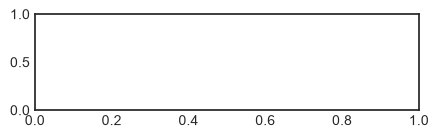

In [90]:
%matplotlib inline
plt.style.use('seaborn-v0_8-white')
#plt.axes()
plt.axes([0.65,65,0.6,0.2])

In [83]:
plt.style.available?


Type:        list
String form: ['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'gr <...> k', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Length:      28
Docstring:  
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.

In [51]:
iris.data[['petal width (cm)','petal length (cm)']]

,petal width (cm),petal length (cm)
0,0.2,1.4
1,0.2,1.4
2,0.2,1.3
3,0.2,1.5
4,0.2,1.4
...,...,...
145,2.3,5.2
146,1.9,5.0
147,2.0,5.2
148,2.3,5.4


In [53]:
iris.data.head() 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [79]:
import .<int>

SyntaxError: invalid syntax (2702916379.py, line 1)

In [55]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
logis_reg=LogisticRegression()

X=iris.data[['petal width (cm)']].values
y=iris.target_names[iris.target]=='virginica'
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
logis_reg.fit(X_train,y_train) # fitting data into model


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [46]:
X_new =np.linspace(0,3 ,1000)
print('shape of X_new==',X_new.shape, 
      '\nshape of the X_new after reshape=',X_new.reshape(-1,1).shape)

shape of X_new== (1000,) 
shape of the X_new after reshape= (1000, 1)


In [80]:
pd.DataFrame(y_predicted_prob)

,0,1
0,0.998208,0.001792
1,0.998187,0.001813
2,0.998166,0.001834
3,0.998145,0.001855
4,0.998124,0.001876
...,...,...
995,0.005924,0.994076
996,0.005856,0.994144
997,0.005790,0.994210
998,0.005724,0.994276


In [83]:
y_predicted_prob

array([[0.99820801, 0.00179199],
       [0.99818732, 0.00181268],
       [0.99816638, 0.00183362],
       ...,
       [0.00578965, 0.99421035],
       [0.00572381, 0.99427619],
       [0.00565872, 0.99434128]], shape=(1000, 2))

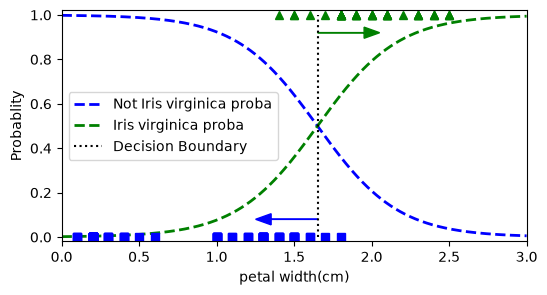

In [194]:
X_new =np.linspace(0,3 ,1000).reshape(-1,1) # reshapping data
y_predicted_prob=logis_reg.predict_proba(X_new)
decision_boundary=X_new[y_predicted_prob [:,1]>=0.5][0,0]
plt.figure(figsize=(6,3))
plt.plot(X_new,y_predicted_prob [:,0],"b--", linewidth=2,label='Not Iris virginica proba')
plt.plot(X_new,y_predicted_prob [:,1],"g--", linewidth=2,label='Iris virginica proba')
plt.plot([decision_boundary,decision_boundary],[0,1],"k:",label="Decision Boundary")
plt.arrow(x=decision_boundary,y=0.08,dx=-0.3,dy=0,
             head_width=0.05,head_length=0.1,fc="b",ec="b")
plt.arrow(x=decision_boundary,y=0.92,dx=0.3,dy=0,
           head_width=0.05,head_length=0.1,fc="g",ec="g")
plt.plot(X_train[y_train==0],y_train[y_train==0],"bs")
plt.plot(X_train[y_train==1],y_train[y_train==1],"g^")
plt.xlabel("petal width(cm)")
plt.ylabel("Probablity")
plt.legend(loc="center left")
plt.axis([0,3,-0.02,1.02])
plt.show()

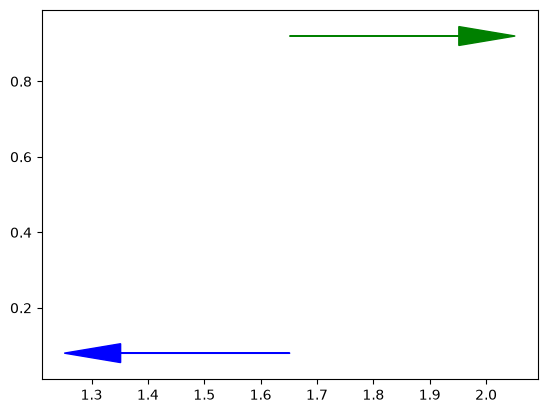

In [184]:
plt.arrow(x=decision_boundary,y=0.08,dx=-0.3,dy=0,
             head_width=0.05,head_length=0.1,fc="b",ec="b")
plt.arrow(x=decision_boundary,y=0.92,dx=0.3,dy=0,
           head_width=0.05,head_length=0.1,fc="g",ec="g");

In [81]:
y_predicted_prob[:,1>=0.5][0,0]#[:,1].shape
X_new[y_predicted_prob [:,1]>=0.5][1,0]

np.float64(1.6546546546546546)

In [78]:
y_predicted_prob[:,1>=0.5][0,0]

array([0.99820801, 0.00179199])

In [77]:
decision_boundary

np.float64(1.6516516516516517)

In [200]:
# for 2 features  == petal length (cm),'petal width (cm)'
X=iris.data[['petal length (cm)','petal width (cm)']].values
y=iris.target_names[iris.target]=='virginica'

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
logis_reg=LogisticRegression(C=2,random_state=42)
logis_reg.fit(X_train,y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver 

In [117]:
a=np.array([1,2,3])
b=np.array([4,5,6])

%timeit np.meshgrid(a,b)
#np.c_[a,b] , 'and', np.c_[n,m] ," and ", np.c_[n.ravel(),m.ravel()]?


33.1 μs ± 2.31 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [118]:
np.random.seed(0)
values=np.random.randint(1,10,size=5)
print(1.0/values)


[0.16666667 1.         0.25       0.25       0.125     ]


In [147]:
x = np.array([1, 2, 3])
y = np.array([10, 20, 30])
X, Y = np.meshgrid(x, y)
#Xnew=np.c_[X.ravel(),Y.ravel()]
Xnew

array([[ 1, 10],
       [ 2, 10],
       [ 3, 10],
       [ 1, 20],
       [ 2, 20],
       [ 3, 20],
       [ 1, 30],
       [ 2, 30],
       [ 3, 30]])

In [209]:
zz=y_proba[:,1].reshape(x0.shape)


array([[2.34846007e-04, 2.40822031e-04, 2.46950087e-04, ...,
        9.84254591e-01, 9.84639403e-01, 9.85014954e-01],
       [2.40983831e-04, 2.47116003e-04, 2.53404178e-04, ...,
        9.84649561e-01, 9.85024867e-01, 9.85391134e-01],
       [2.47282032e-04, 2.53574429e-04, 2.60026904e-04, ...,
        9.85034774e-01, 9.85400802e-01, 9.85758007e-01],
       ...,
       [3.65243062e-02, 3.74191617e-02, 3.83350692e-02, ...,
        9.99900883e-01, 9.99903343e-01, 9.99905742e-01],
       [3.74433669e-02, 3.83598432e-02, 3.92978357e-02, ...,
        9.99903408e-01, 9.99905805e-01, 9.99908143e-01],
       [3.83846327e-02, 3.93232065e-02, 4.02837688e-02, ...,
        9.99905869e-01, 9.99908205e-01, 9.99910483e-01]], shape=(200, 500))

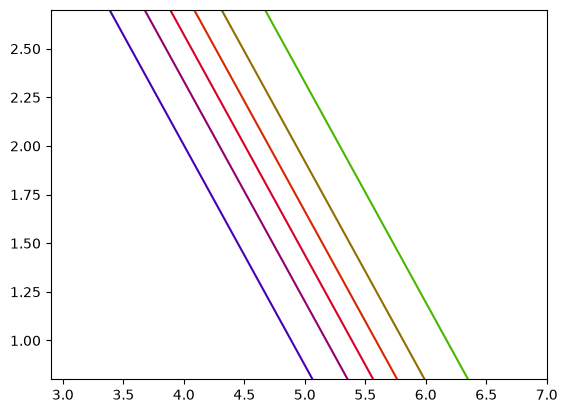

Type:           QuadContourSet
String form:    <matplotlib.contour.QuadContourSet object at 0x000002194025DC50>
File:           c:\users\pc\projects\ml-from-scratch\venv\lib\site-packages\matplotlib\contour.py
Docstring:     
Create and store a set of contour lines or filled regions.

This class is typically not instantiated directly by the user but by
`~.Axes.contour` and `~.Axes.contourf`.


Attributes
----------
levels : array
    The values of the contour levels.

layers : array
    Same as levels for line contours; half-way between
    levels for filled contours.  See ``ContourSet._process_colors``.
Init docstring:
Draw contour lines or filled regions, depending on
whether keyword arg *filled* is ``False`` (default) or ``True``.

Call signature::

    ContourSet(ax, levels, allsegs, [allkinds], **kwargs)

Parameters
----------
ax : `~matplotlib.axes.Axes`
    The `~.axes.Axes` object to draw on.

levels : [level0, level1, ..., leveln]
    A list of floating point numbers indicatin

In [303]:
contour=plt.contour(x0,x1,zz,cmap=plt.cm.brg);
#plt.clabel(contour,inline=1)
contour?


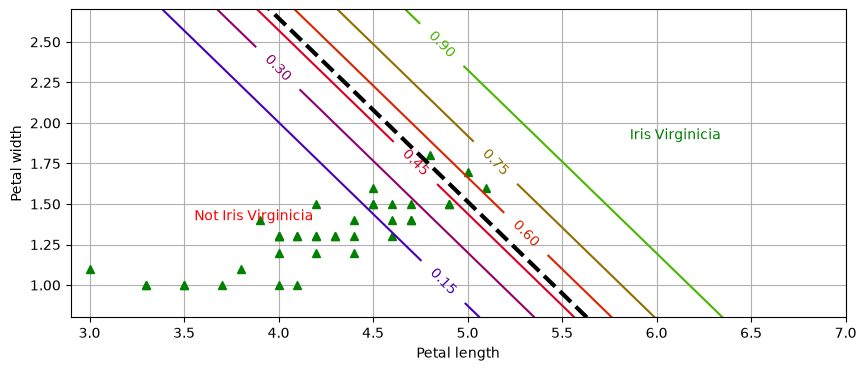

In [365]:

x0,x1=np.meshgrid(np.linspace(2.9,7 ,500).reshape(-1,1),
                  np.linspace(0.8,2.7,200).reshape(-1,1)) # creating 2D grid matrix

X_new=np.c_[x0.ravel(),x1.ravel()] # Flatten and stack into 2D array matrix
y_proba=logis_reg.predict_proba(X_new)
zz=y_proba[:,1].reshape(x0.shape)
 # extracting learned intercept

b0=logis_reg.coef_[0][0] # weight length of petal
b1=logis_reg.coef_[0][1] # weight width of petal
width_rang=np.array([2.9,7]) #sequence of input points along the horizontal x-axis as petal width

# Calculate the matching y values (petal lengths) using algebra
# length = -(b0 + b1 * width) / b2

boundary=-((logis_reg.intercept_[0] + b0*width_rang)/b1 )

plt.figure(figsize=(10,4))
plt.plot(X_train[y_train==0,0],X_train[y_train==0,1],"bs")
plt.plot(X_train[y_train==1,0],X_train[y_train==1,1],"g^")
contour=plt.contour(x0,x1,zz,cmap=plt.cm.brg)
plt.clabel(contour,inline=1)
plt.plot(width_rang,boundary,"k--",linewidth=3);
plt.text(6.1,1.9, "Iris Virginicia",color='g', ha='center')
plt.text(3.87,1.4,"Not Iris Virginicia", color='r',ha='center')
plt.axis([2.9,7,0.8,2.7])
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.show()

##  Softmax Regression 
 * `The Logistic Regression model` can be generalized to support `multiple classes` directly,
without having to train and combine multiple binary classifiers.This is called **`Softmax Regression`, or `Multinomial Logistic Regression`**.

*  *The idea is, when given an instance *`x`*, the **`Softmax Regression`** model
first computes a *`score s(x)`* for each class *`k`*, then estimates the probability of each
class by applying the softmax function **(also called the normalized exponential)** to the
scores*.

* *Once you have computed the score of every class for the instance x, you can estimate
the probability k that the instance belongs to class k by running the scores through
the softmax function.*
* **`The Softmax Regression classifier predicts only one class at a time
(i.e., it is multiclass, not multioutput) so it should be used only with
mutually exclusive classes such as different types of plants. You
cannot use it to recognize multiple people in one picture`**.

 **Note**: *Cross entropy measures the average number of bits you actually send per option.*

In [320]:
iris.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [307]:
iris.data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [312]:
iris.data[['petal length (cm)','petal width (cm)']]

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [331]:
# Softmax regression implementation
X=iris.data[['petal length (cm)','petal width (cm)']].values
y=iris['target']

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)
softmax_reg=LogisticRegresjsion(C=30,random_state=42)
softmax_reg.fit(X_train,y_train)


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",30
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [333]:
softmax_reg.predict([[5,2]]) # predicted class for [[5,2]] instance 

array([2])

In [336]:
softmax_reg.predict_proba([[5,2]]) # probablity of each class in the instance 
                                   # now in this instance [[5,2]] Iris-Viriginicia is 95.9%.

array([[3.37167169e-08, 4.06723544e-02, 9.59327612e-01]])

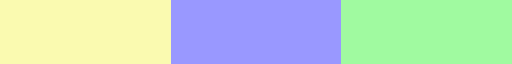

In [376]:
from matplotlib.colors import ListedColormap

custom_cmap=ListedColormap(["#fafab0", "#9998ff", "#a0faa0"])
custom_cmap

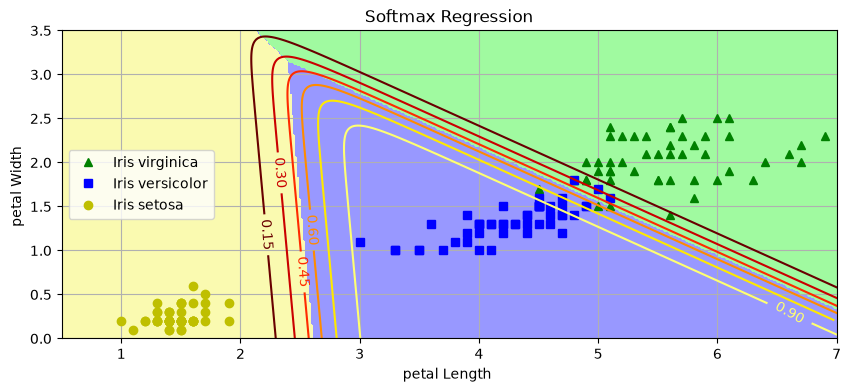

In [369]:
from matplotlib.colors import ListedColormap

custom_cmap=ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0,x1=np.meshgrid(np.linspace(0,8,500).reshape(-1,1),
                  
                 np.linspace(0,3.5,200).reshape(-1,1))

X_new=np.c_[x0.ravel(),x1.ravel()]

y_proba=softmax_reg.predict_proba(X_new)

y_predict=softmax_reg.predict(X_new)

zz=y_predict.reshape(x0.shape)
zz1=y_proba[:,1].reshape(x0.shape)
plt.figure(figsize=(10,4))
plt.plot(X[y==2,0],X[y==2,1],'g^',label="Iris virginica") # Viriginicia class
plt.plot(X[y==1,0],X[y==1,1],'bs',label="Iris versicolor")
plt.plot(X[y==0,0],X[y==0,1],'yo',label="Iris setosa");
plt.contourf(x0,x1,zz,cmap=custom_cmap)
contour=plt.contour(x0,x1,zz1,cmap='hot')
plt.clabel(contour, inline=1)
plt.xlabel('petal Length ')
plt.ylabel('petal Width ')
plt.legend(loc='center left')
plt.title("Softmax Regression")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
plt.show()